# Frequency Analysis & Score Computation
This notebook computes a weighted frequency score for each user–product pair
based on Instacart’s dataset (`orders.csv` and `order_products__prior.csv`).

Steps:
1. Load and inspect data
2. Merge tables
3. Apply weight decay (recency-based)
4. Compute frequency score per (user, product)
5. Normalize scores
6. Export results (and optionally prepare for SVD)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

In [3]:
data_path = "../../data/"

orders_path = os.path.join(data_path, "orders.csv")
order_products_path = os.path.join(data_path, "order_products__prior.csv")

orders = pd.read_csv(orders_path)
order_products = pd.read_csv(order_products_path)

print("Orders shape:", orders.shape)
print("Order products shape:", order_products.shape)
orders.head()

Orders shape: (3421083, 7)
Order products shape: (32434489, 4)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [4]:
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


### Merge Orders and Products

This step combines the `orders` and `order_products__prior` tables using the common key `order_id`.  
The goal is to link each product purchase (`product_id`) to the corresponding `user_id` from the `orders` table.  
An inner join ensures we only keep matching records that appear in both datasets.

In [5]:
merged = orders.merge(order_products, on='order_id', how='inner')
print(merged.shape)
merged.head()

(32434489, 10)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,2539329,1,prior,1,2,8,NaN,196,1,0
1,2539329,1,prior,1,2,8,NaN,14084,2,0
2,2539329,1,prior,1,2,8,NaN,12427,3,0
3,2539329,1,prior,1,2,8,NaN,26088,4,0
4,2539329,1,prior,1,2,8,NaN,26405,5,0


In [6]:
λ = 0.1
merged['weight'] = np.exp(-λ * merged['days_since_prior_order'].fillna(0))
merged[['user_id', 'product_id', 'days_since_prior_order', 'weight']].head()

,user_id,product_id,days_since_prior_order,weight
0,1,196,NaN,1.0
1,1,14084,NaN,1.0
2,1,12427,NaN,1.0
3,1,26088,NaN,1.0
4,1,26405,NaN,1.0


In [7]:
λ = 0.0015  # smaller λ keeps longer memory

# replace NaN for first orders
merged['days_since_prior_order'] = merged['days_since_prior_order'].fillna(0)

# sort to compute cumulative time for each user
merged = merged.sort_values(['user_id', 'order_number'])

# cumulative days since first order
merged['cum_days'] = merged.groupby('user_id')['days_since_prior_order'].cumsum()

# total days each user is active
merged['total_days'] = merged.groupby('user_id')['days_since_prior_order'].transform('sum')

# age_days = time until last order
merged['age_days'] = merged['total_days'] - merged['cum_days']

# exponential weight based on recency
merged['weight'] = np.exp(-λ * merged['age_days'])

sample_user_id = merged['user_id'].iloc[0]
sample = merged.loc[merged['user_id'] == sample_user_id, ['user_id', 'order_number', 'days_since_prior_order', 'cum_days', 'total_days', 'age_days', 'weight']]
display(sample.head(10))

,user_id,order_number,days_since_prior_order,cum_days,total_days,age_days,weight
0,1,1,0.0,0.0,1094.0,1094.0,0.193786
1,1,1,0.0,0.0,1094.0,1094.0,0.193786
2,1,1,0.0,0.0,1094.0,1094.0,0.193786
3,1,1,0.0,0.0,1094.0,1094.0,0.193786
4,1,1,0.0,0.0,1094.0,1094.0,0.193786
5,1,2,15.0,15.0,1094.0,1079.0,0.198196
6,1,2,15.0,30.0,1094.0,1064.0,0.202706
7,1,2,15.0,45.0,1094.0,1049.0,0.207318
8,1,2,15.0,60.0,1094.0,1034.0,0.212036
9,1,2,15.0,75.0,1094.0,1019.0,0.216861


### Exponential Decay Formula

The weight for each purchase is calculated using the **exponential decay** function:

$$
w = e^{-\lambda \cdot t}
$$

where:  
- **w** → resulting weight  
- **λ** → decay rate (controls how quickly importance fades over time)  
- **t** → number of days since the last purchase  

*Raise e (≈ 2.718) to the power of -λ·t*.  
This produces a **smooth, continuous decay** in the weight:

- For small *t*, the value of **e^(-λt)** is close to **1**, meaning **recent purchases remain highly important**.  
- For large *t*, the value approaches **0**, meaning **older purchases gradually lose their influence**.  

This exponential behavior ensures that importance **drops quickly at first** and then **slows down over time**,  
closely mirroring how users naturally forget or give less relevance to older purchases.

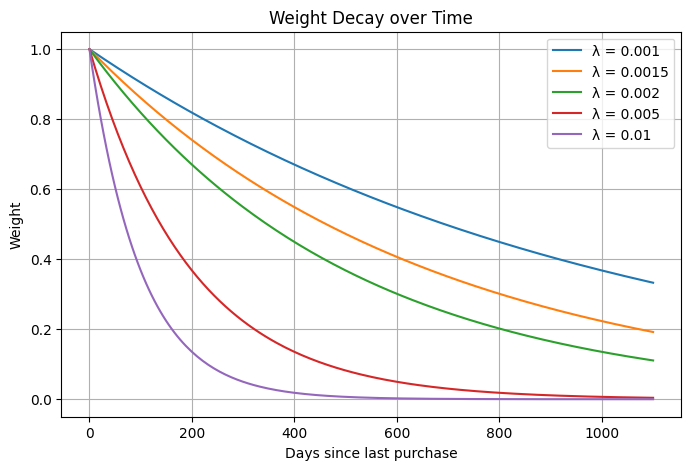

In [8]:
age_days = np.linspace(0, 1100, 200)
lambdas = [0.001, 0.0015, 0.002, 0.005, 0.01]

plt.figure(figsize=(8, 5))
for l in lambdas:
    weights = np.exp(-l * age_days)
    plt.plot(age_days, weights, label=f'λ = {l}')

plt.title("Weight Decay over Time")
plt.xlabel("Days since last purchase")
plt.ylabel("Weight")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of the Weight Decay Plot

The plot shows how purchase importance (weight) decreases over time for different decay rates (λ).  
Smaller λ values decay slowly, keeping long-term purchases relevant, while larger λ values decay quickly, emphasizing recent activity.

- **λ = 0.001:** Very slow decay — long-term habits stay important.  
- **λ = 0.0015:** Balanced decay — good trade-off between recency and history.  
- **λ = 0.002:** Moderate decay — focuses on the last few months.  
- **λ = 0.005:** Fast decay — only recent orders matter.  
- **λ = 0.01:** Very fast decay — ignores anything older than ~100 days.

I think, **λ = 0.0015** is the most balanced choice.

In [9]:
freq = (
    merged.groupby(['user_id', 'product_id'])['weight']
    .sum()
    .reset_index(name='score')
)

display(freq.head())

,user_id,product_id,score
0,1,196,4.192653
1,1,10258,4.304592
2,1,10326,0.398121
3,1,12427,4.570855
4,1,13032,1.765810


### Interpreting the Final Score

The final **score** for each `(user_id, product_id)` pair is not an average,  
but the **sum of all recency-weighted purchases** made by the user for that product.

Each individual purchase has a weight between **0 and 1**, depending on how recent it was.  
If a user buys the same product multiple times, and those purchases are fairly recent  
(e.g., weights of 0.8, 0.9, 0.95...), the total score can easily exceed 1.0.

- A **score > 1.0** indicates strong user preference:  
  the user has purchased this product several times and recently.  
- A **higher score** means the product is more characteristic or important for that user.  
  For example, a product with a score of **4.5** represents a consistent, repeated purchase,  
  while a score around **0.5** indicates occasional or older purchases.

In [10]:
georgios_path = os.path.join(data_path, "Georgios")
os.makedirs(georgios_path, exist_ok=True)

csv_path = os.path.join(georgios_path, "user_product_recency.csv")
parquet_path = os.path.join(georgios_path, "user_product_recency.parquet")

freq.to_csv(csv_path, index=False)
freq.to_parquet(parquet_path, index=False)
print(f"Saved raw recency results to: {csv_path}")
print(f"Saved raw recency results to: {parquet_path}")

# Normalization (min–max scaling)
freq['normalized_score'] = (
    (freq['score'] - freq['score'].min()) /
    (freq['score'].max() - freq['score'].min())
)

csv_path_norm = os.path.join(georgios_path, "user_product_recency_normalized.csv")
parquet_path_norm = os.path.join(georgios_path, "user_product_recency_normalized.parquet")

freq.to_csv(csv_path_norm, index=False)
freq.to_parquet(parquet_path_norm, index=False)
print(f"Saved normalized recency results to: {csv_path_norm}")
print(f"Saved normalized recency results to: {parquet_path_norm}")

freq.head()

Saved raw recency results to: ../../data/Georgios\user_product_recency.csv
Saved raw recency results to: ../../data/Georgios\user_product_recency.parquet
Saved normalized recency results to: ../../data/Georgios\user_product_recency_normalized.csv
Saved normalized recency results to: ../../data/Georgios\user_product_recency_normalized.parquet


,user_id,product_id,score,normalized_score
0,1,196,4.192653,0.050238
1,1,10258,4.304592,0.051580
2,1,10326,0.398121,0.004770
3,1,12427,4.570855,0.054770
4,1,13032,1.765810,0.021159
